In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================
# 1. Load dataset
# =========================
# Make sure LSWMD.pkl is in the same directory
df = pd.read_pickle("LSWMD.pkl")

print("Dataset loaded.")
print("Shape:", df.shape)
print("Columns:", df.columns)

Dataset loaded.
Shape: (811457, 6)
Columns: Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [2]:
# =========================
# 2. Convert failureType to clean label
# =========================
def to_label(x):
    x = np.array(x)
    if x.size == 0:
        return "unknown"
    return str(x.ravel()[0])

df["label"] = df["failureType"].apply(to_label)

print("Unique labels:", df["label"].unique())

Unique labels: ['none' 'Loc' 'unknown' 'Edge-Loc' 'Center' 'Edge-Ring' 'Scratch' 'Random'
 'Near-full' 'Donut']


In [3]:
# =========================
# 3. Extract failure modes (exclude normal and unknown)
# =========================
modes = df["label"].unique()
modes = [m for m in modes if m not in ["none", "unknown"]]

print("Failure modes:", modes)

Failure modes: ['Loc', 'Edge-Loc', 'Center', 'Edge-Ring', 'Scratch', 'Random', 'Near-full', 'Donut']


In [4]:
# =========================
# 4. Select one representative wafer per failure mode
# =========================
representatives = []

for mode in modes:
    sample = df[df["label"] == mode].iloc[0]
    representatives.append((mode, sample["waferMap"]))

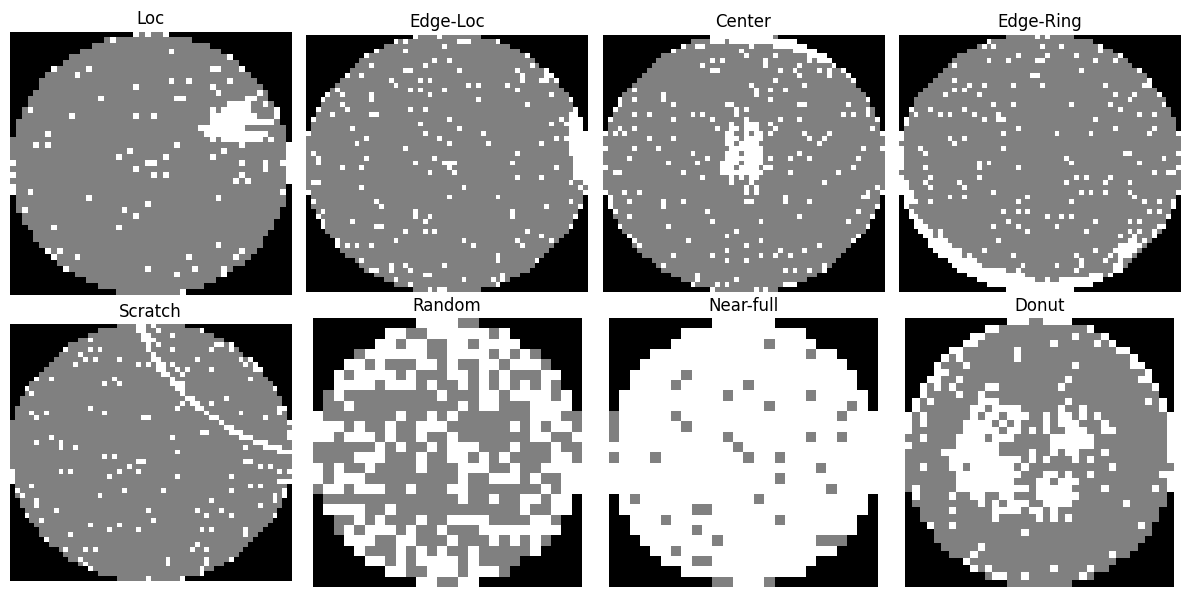

In [5]:
# =========================
# 5. Plot all failure modes
# =========================
n = len(representatives)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*3, rows*3))

for i, (mode, wafer) in enumerate(representatives):
    plt.subplot(rows, cols, i+1)
    plt.imshow(np.array(wafer), cmap="gray")
    plt.title(mode)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# =========================
# 6. Compression function (52x52 → 8x8)
# =========================

def wafer52_to_8x8_major_vote(wafer52, defect_value=2, threshold=0.20):
    a = np.array(wafer52)
    b = (a == defect_value).astype(np.uint8)

    row_blocks = np.array_split(b, 8, axis=0)
    out = np.zeros((8, 8), dtype=np.uint8)

    for i, rb in enumerate(row_blocks):
        col_blocks = np.array_split(rb, 8, axis=1)
        for j, block in enumerate(col_blocks):
            out[i, j] = 1 if block.mean() >= threshold else 0

    return out

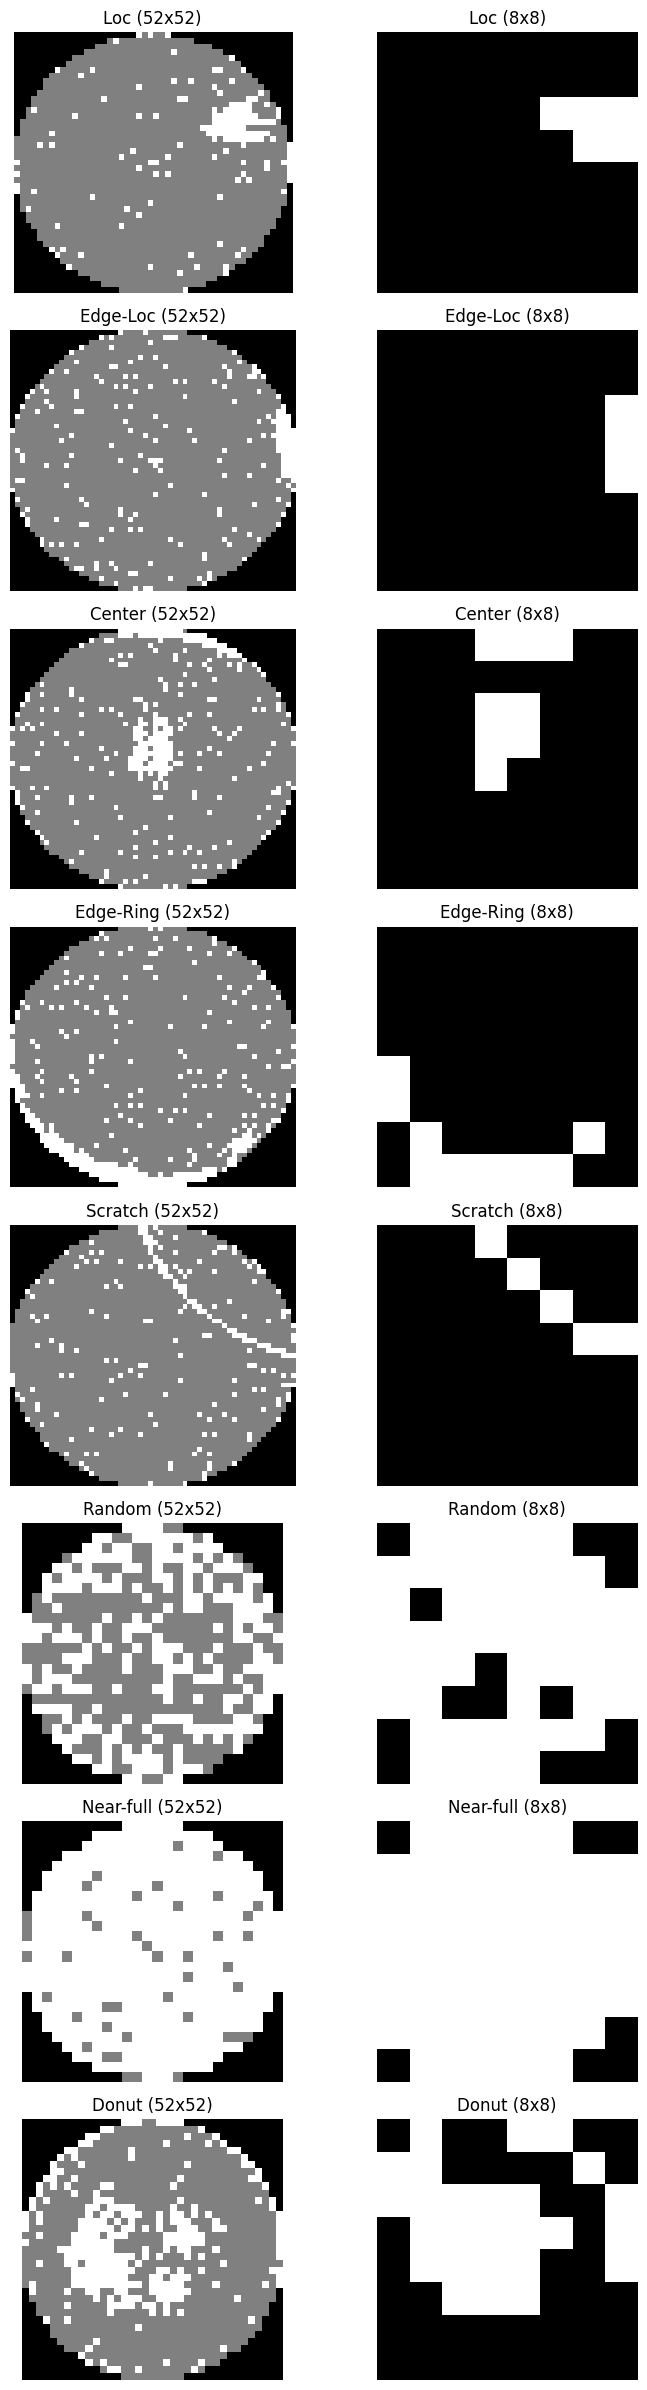

In [7]:
#=========================
#7. Plot representative wafers (Original vs Compressed)
#=========================

# Compress representatives
representatives_compressed = []

for mode in modes:
    sample = df[df["label"] == mode].iloc[0]
    w52 = np.array(sample["waferMap"])
    w8  = wafer52_to_8x8_major_vote(w52, threshold=0.20)
    representatives_compressed.append((mode, w52, w8))

n = len(representatives_compressed)
rows = n
cols = 2

plt.figure(figsize=(8, rows*3))

for i, (mode, w52, w8) in enumerate(representatives_compressed):

    # Left: original 52x52
    plt.subplot(rows, cols, 2*i + 1)
    plt.imshow(w52, cmap="gray")
    plt.title(f"{mode} (52x52)")
    plt.axis("off")

    # Right: compressed 8x8
    plt.subplot(rows, cols, 2*i + 2)
    plt.imshow(w8, cmap="gray", vmin=0, vmax=1)
    plt.title(f"{mode} (8x8)")
    plt.axis("off")

plt.tight_layout()
plt.show()

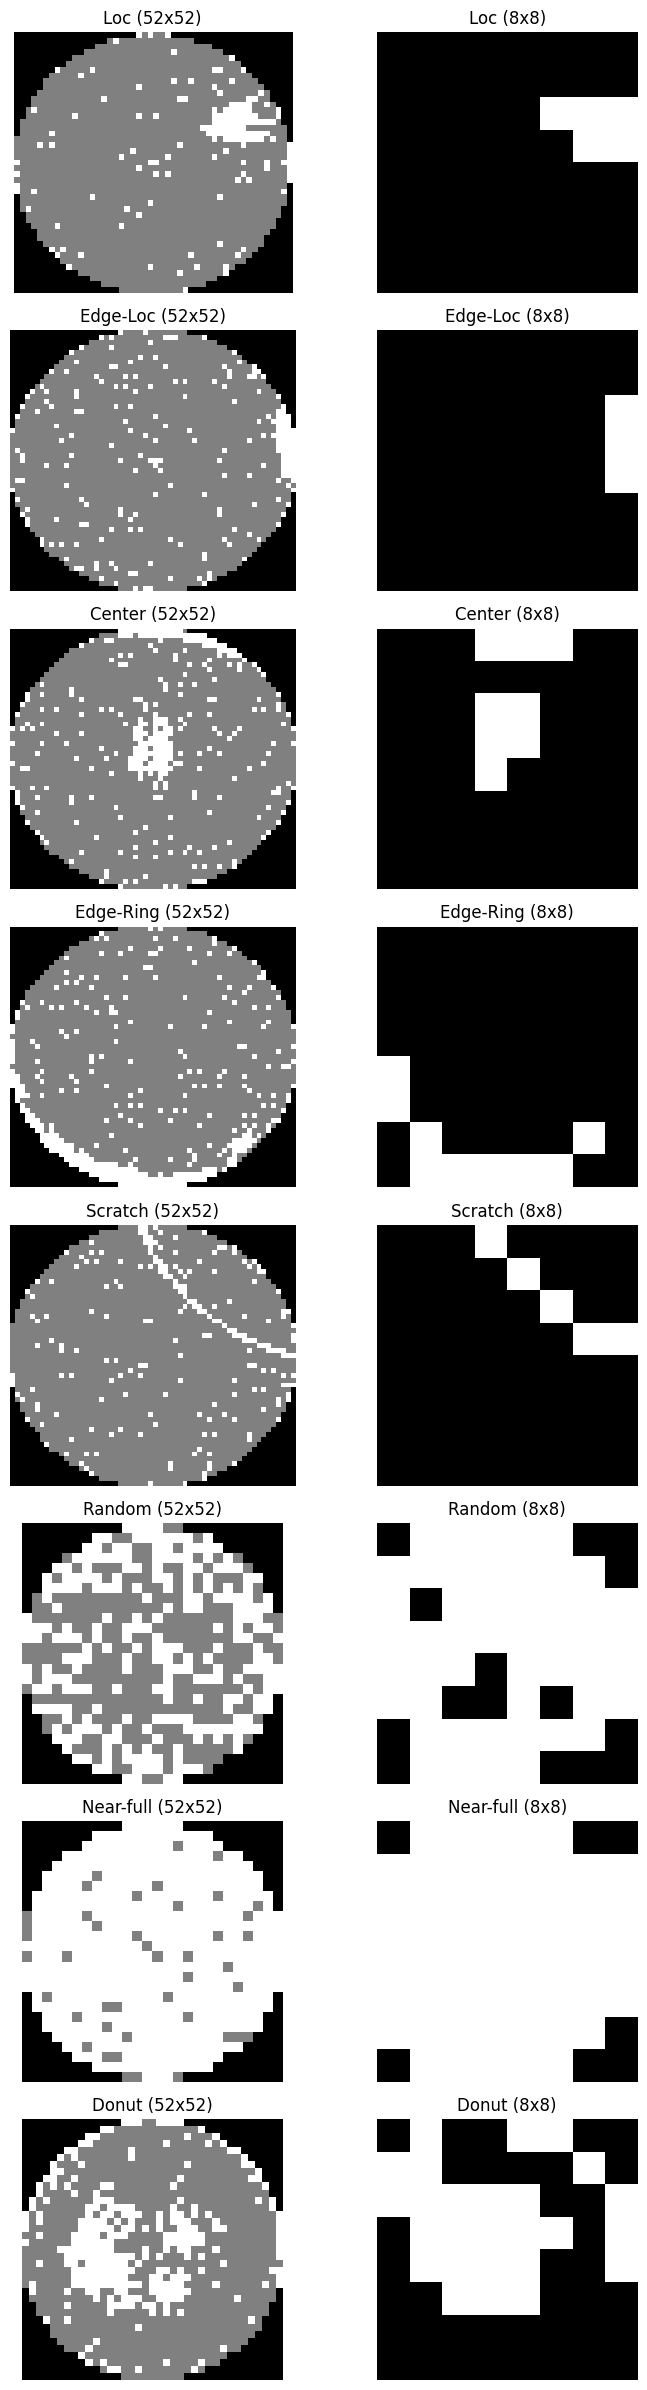